# 10 — Feature Extraction

Which summary statistics carry information about the model parameters, and do the scalar
statistics capture the richer update-matrix (UM) / conditional-psychometric signatures?

This matters for the SBI observation vector: if it is built from scalar stats, we want to know
(a) which stats are informative for each parameter, and (b) whether anything in the UM /
conditional psychometric is *not* reflected in those scalar stats.

The synthetic half is the clean test (one model family, parameters varied over the prior).
The real-data half is only a sanity check — see the caveats there.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
from shared_setup import *

from behav_utils.analysis.summary_stats import (
    list_available_stats, get_stat_names_expanded, flatten_stats, compute_summary_stats,
)
from validation.feature_diagnostics import compute_param_stat_correlations
from plotting.sbi_validation import plot_param_stat_correlations

## Helpers

In [2]:
def stat_groups(names):
    """Column indices for the UM block, the conditional-psychometric block, and everything else."""
    um   = [k for k, n in enumerate(names) if n.startswith('um_')]
    cond = [k for k, n in enumerate(names) if n.startswith('cond_')]
    drop = set(um) | set(cond)
    feat = [k for k in range(len(names)) if k not in drop]
    return feat, um, cond


def feat_only(result):
    """Restrict a compute_param_stat_correlations result to the non-UM/non-cond columns (readable heatmap)."""
    feat, _um, _cond = stat_groups(result['stat_names_expanded'])
    return {
        'corr_matrix':         result['corr_matrix'][:, feat],
        'param_names':         result['param_names'],
        'stat_names_expanded': [result['stat_names_expanded'][k] for k in feat],
    }


def cross_corr(A, B):
    """|Pearson r| between every column of A and every column of B.

    Pairwise-complete over rows, so NaN cells (sparse UM) are tolerated; a constant or
    all-NaN column simply yields NaN for that row/column rather than raising.
    """
    A, B = np.asarray(A, float), np.asarray(B, float)
    a = pd.DataFrame(A, columns=[f'a{i}' for i in range(A.shape[1])])
    b = pd.DataFrame(B, columns=[f'b{j}' for j in range(B.shape[1])])
    C = pd.concat([a, b], axis=1).corr()
    return np.abs(C.loc[a.columns, b.columns].to_numpy())


def plot_cross(corr, row_names, col_names, title, figsize=None):
    if figsize is None:
        figsize = (min(0.4 * len(col_names) + 3, 22), min(0.32 * len(row_names) + 2, 16))
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(corr, aspect='auto', cmap='viridis', vmin=0, vmax=1)
    ax.set_xticks(range(len(col_names))); ax.set_xticklabels(col_names, rotation=90, fontsize=7)
    ax.set_yticks(range(len(row_names))); ax.set_yticklabels(row_names, fontsize=7)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label='|r|')
    plt.tight_layout(); plt.show()

## Synthetic

`compute_param_stat_correlations` samples parameters from the prior, simulates one pooled
session per draw, computes the full stat vector, and returns the per-parameter / per-stat
correlation matrix plus the raw stat vectors (`x`). One call per model replaces the manual
sample → simulate → correlate loop.

**Note on `n_valid`:** any draw whose stat vector is non-finite is dropped. At low `n_trials`
the per-session UM has empty cells (NaN), so the count of dropped draws rises and the
survivors are biased towards parameter sets that happen to fill the UM. Keep `n_trials` high
enough that `n_valid` stays close to `n_samples`; lower it only for a quick pass.

In [3]:
stat_names = list_available_stats()
n_samples, n_trials = 1000, 2000

be = compute_param_stat_correlations('be', stat_names=stat_names, n_samples=n_samples, n_trials=n_trials, seed=0)
sc = compute_param_stat_correlations('sc', stat_names=stat_names, n_samples=n_samples, n_trials=n_trials, seed=0)

print(f"BE: {be['n_valid']}/{n_samples} valid draws, corr matrix {be['corr_matrix'].shape}")
print(f"SC: {sc['n_valid']}/{n_samples} valid draws, corr matrix {sc['corr_matrix'].shape}")

BE: 1000/1000 valid draws, corr matrix (4, 144)
SC: 999/1000 valid draws, corr matrix (4, 144)


### Corr(param, stats)

How strongly each scalar statistic tracks each parameter, across the prior. A parameter with
no bright cell in its row is poorly constrained by this stat set. (UM and conditional-psychometric
columns are dropped here for readability — they are examined as targets in the next section.)

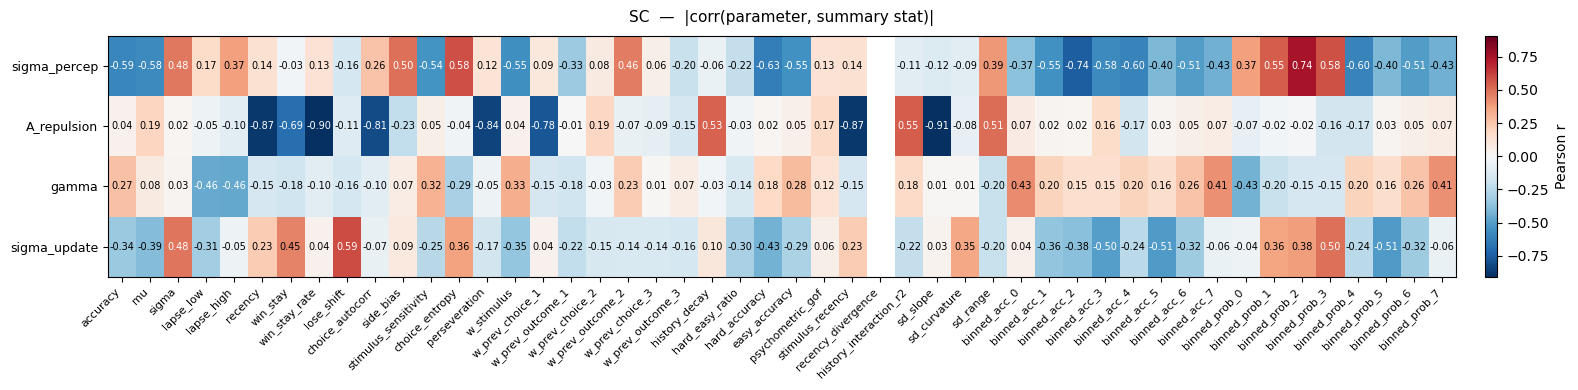

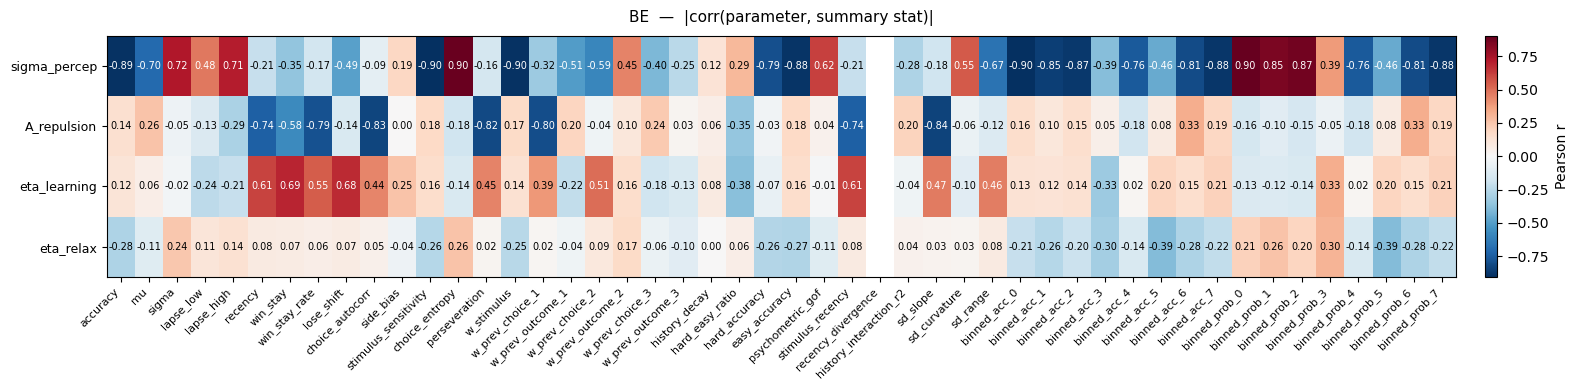

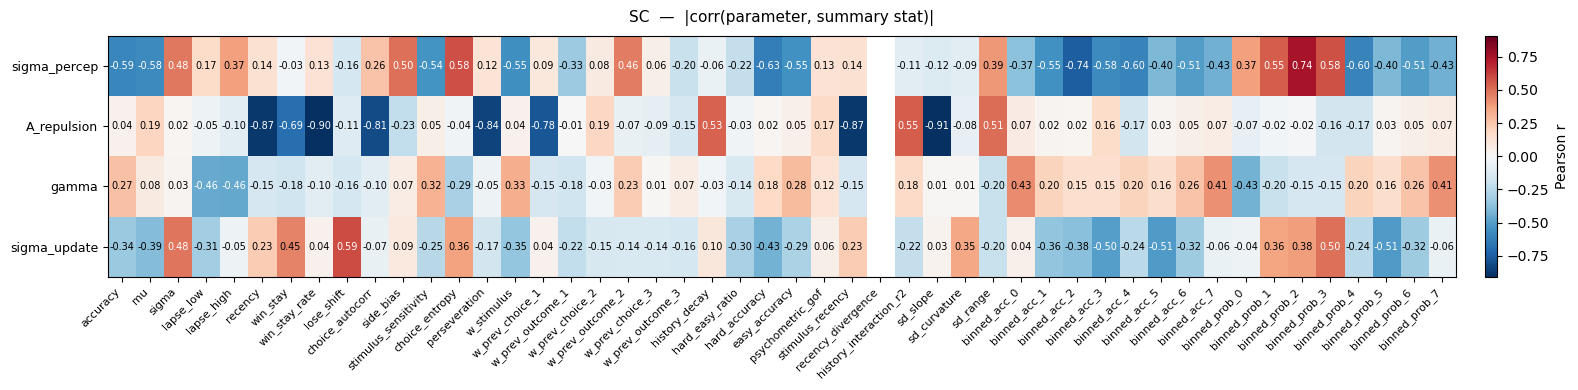

In [4]:
plot_param_stat_correlations(feat_only(be), figsize=(16, 4), title='BE  —  |corr(parameter, summary stat)|')
plot_param_stat_correlations(feat_only(sc), figsize=(16, 4), title='SC  —  |corr(parameter, summary stat)|')

### Corr(UM, stats) and Corr(cond psych, stats)

Treating the UM cells and the conditional-psychometric parameters as *targets*: is each one
tracked by some scalar statistic? A UM cell whose row is dark across all scalar stats is signal
that the scalar vector does not capture it — relevant if SBI is conditioned on scalar stats alone.

This reuses the simulated `x` from the call above (no re-simulation).

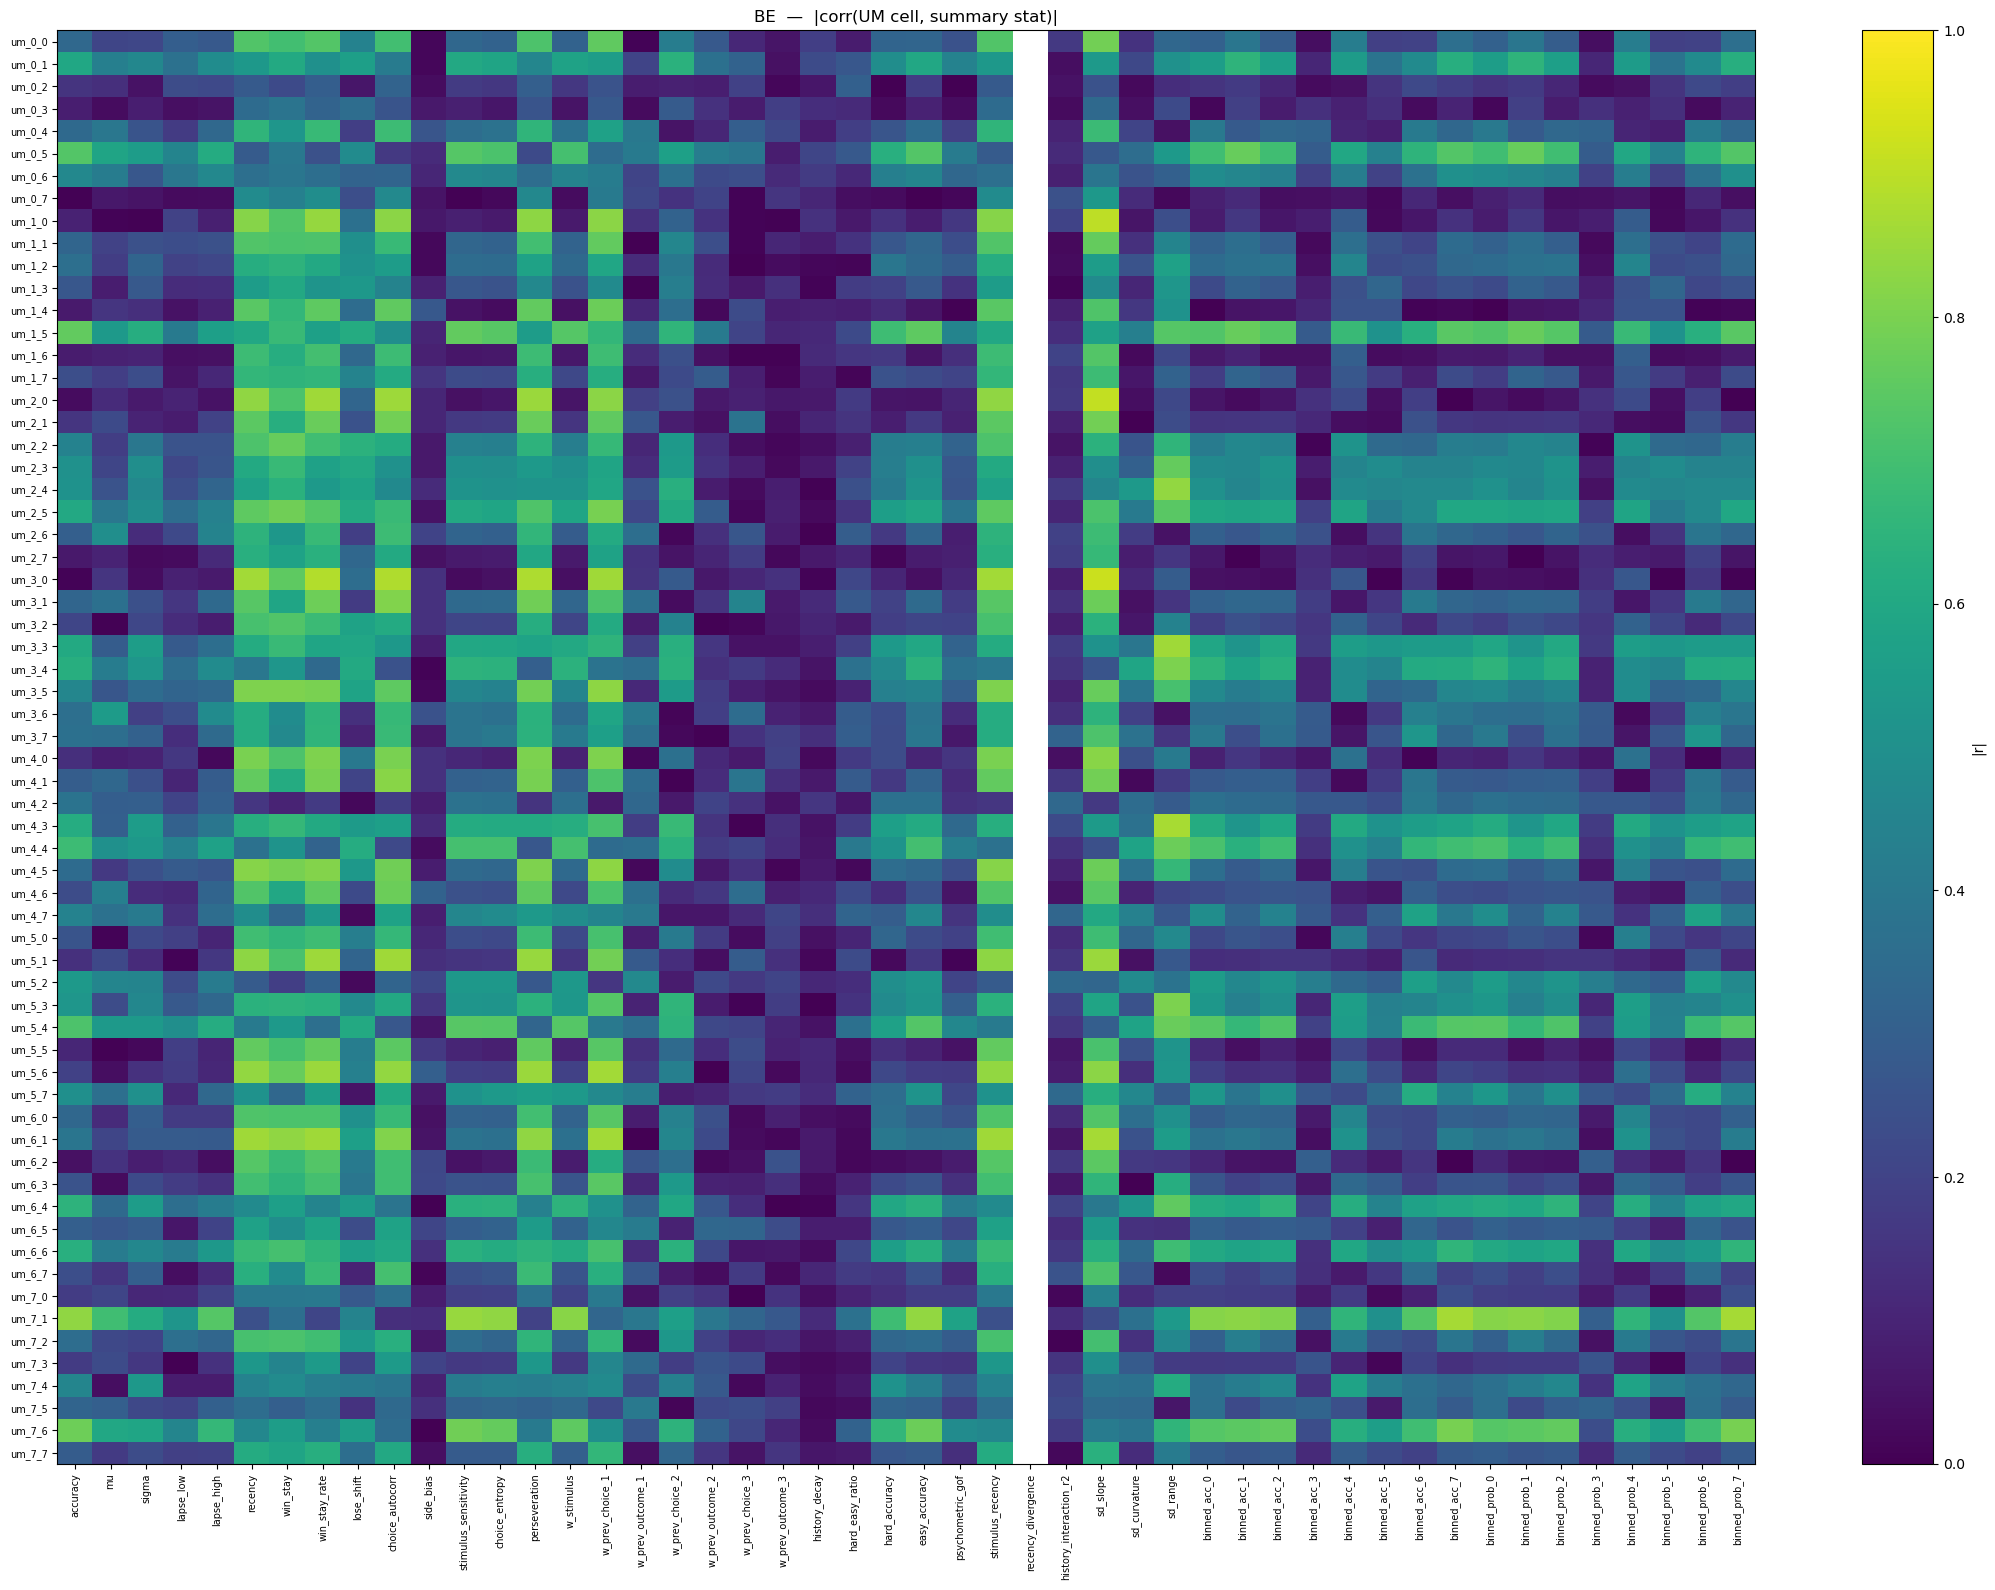

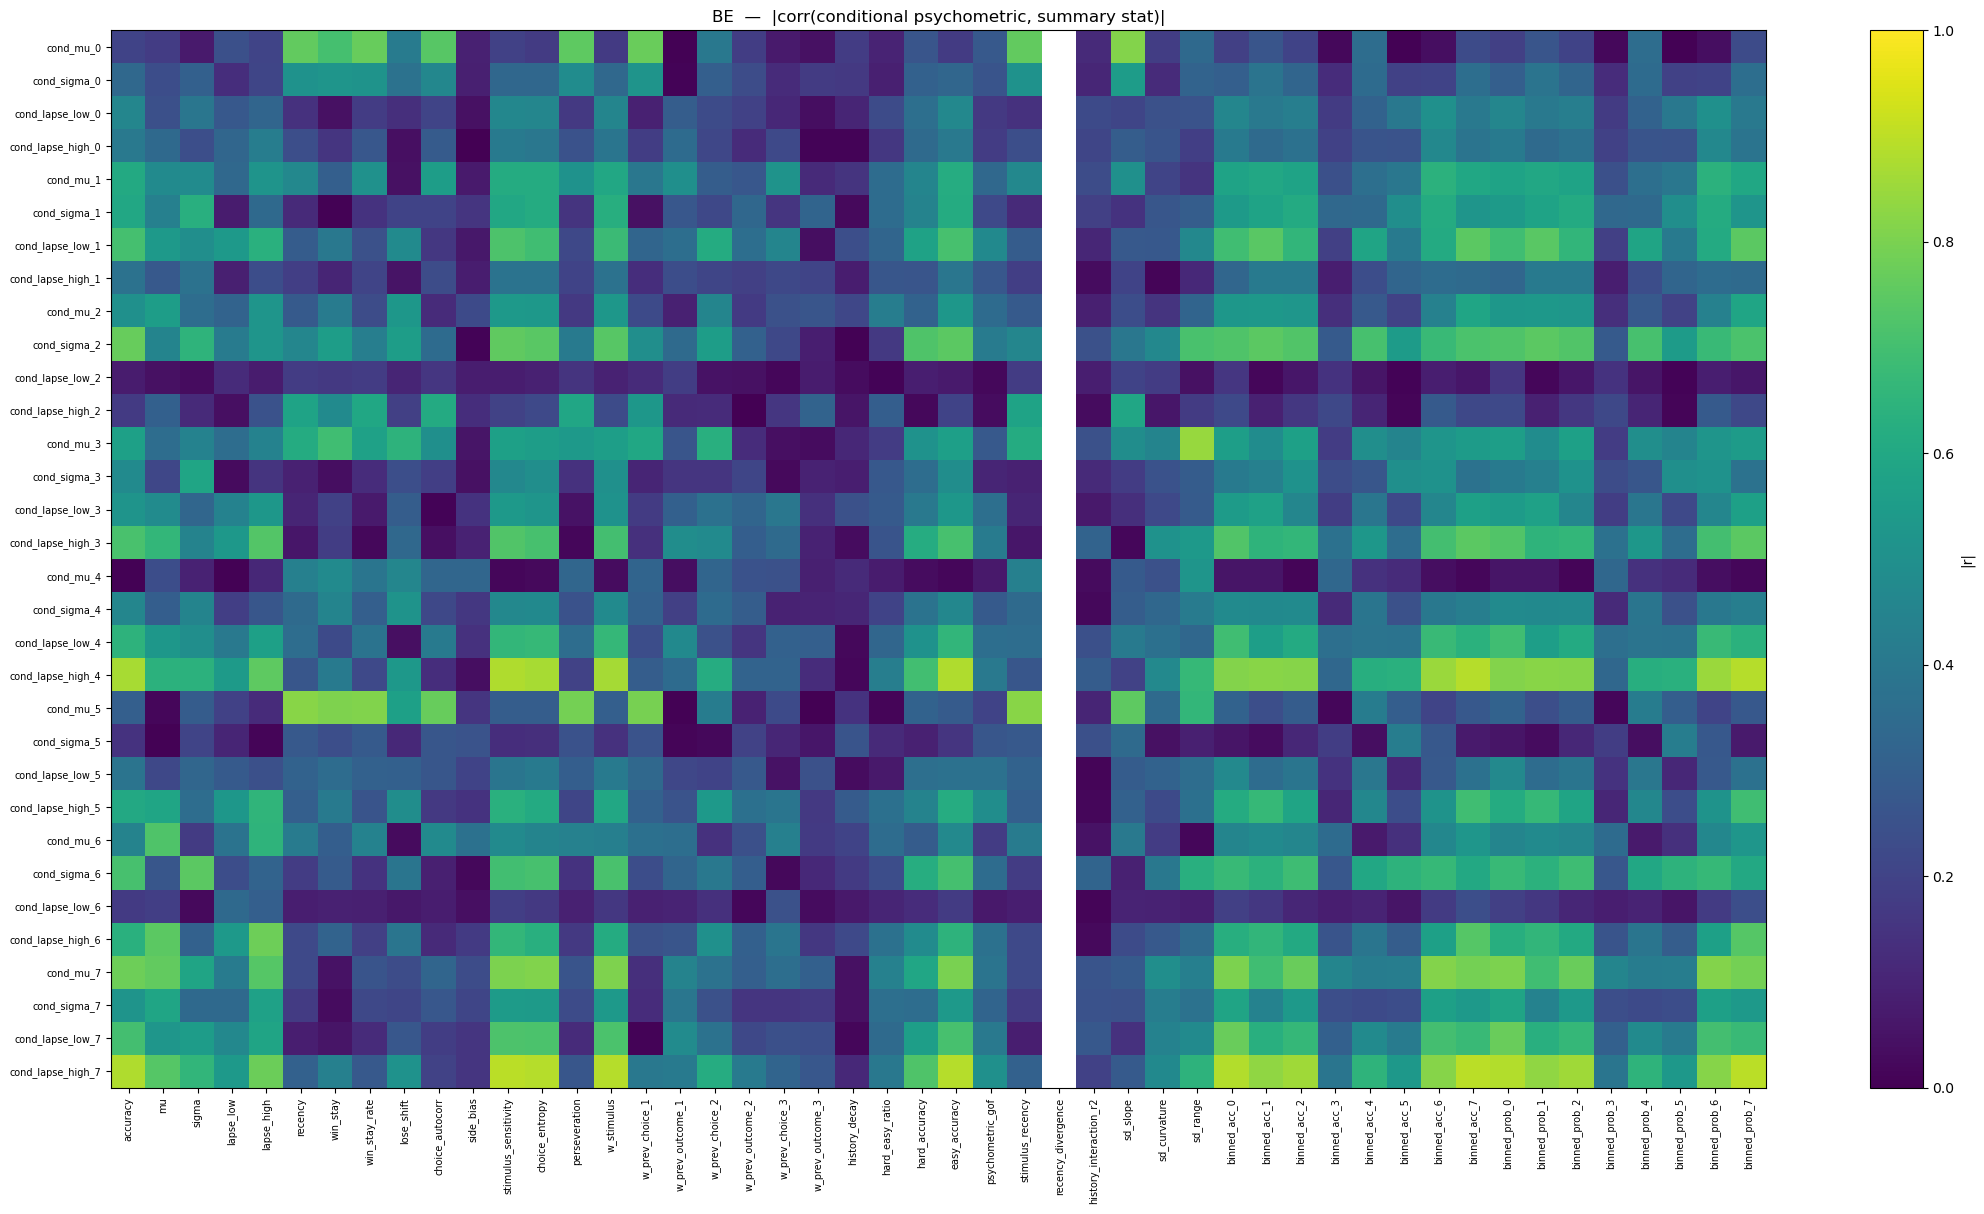

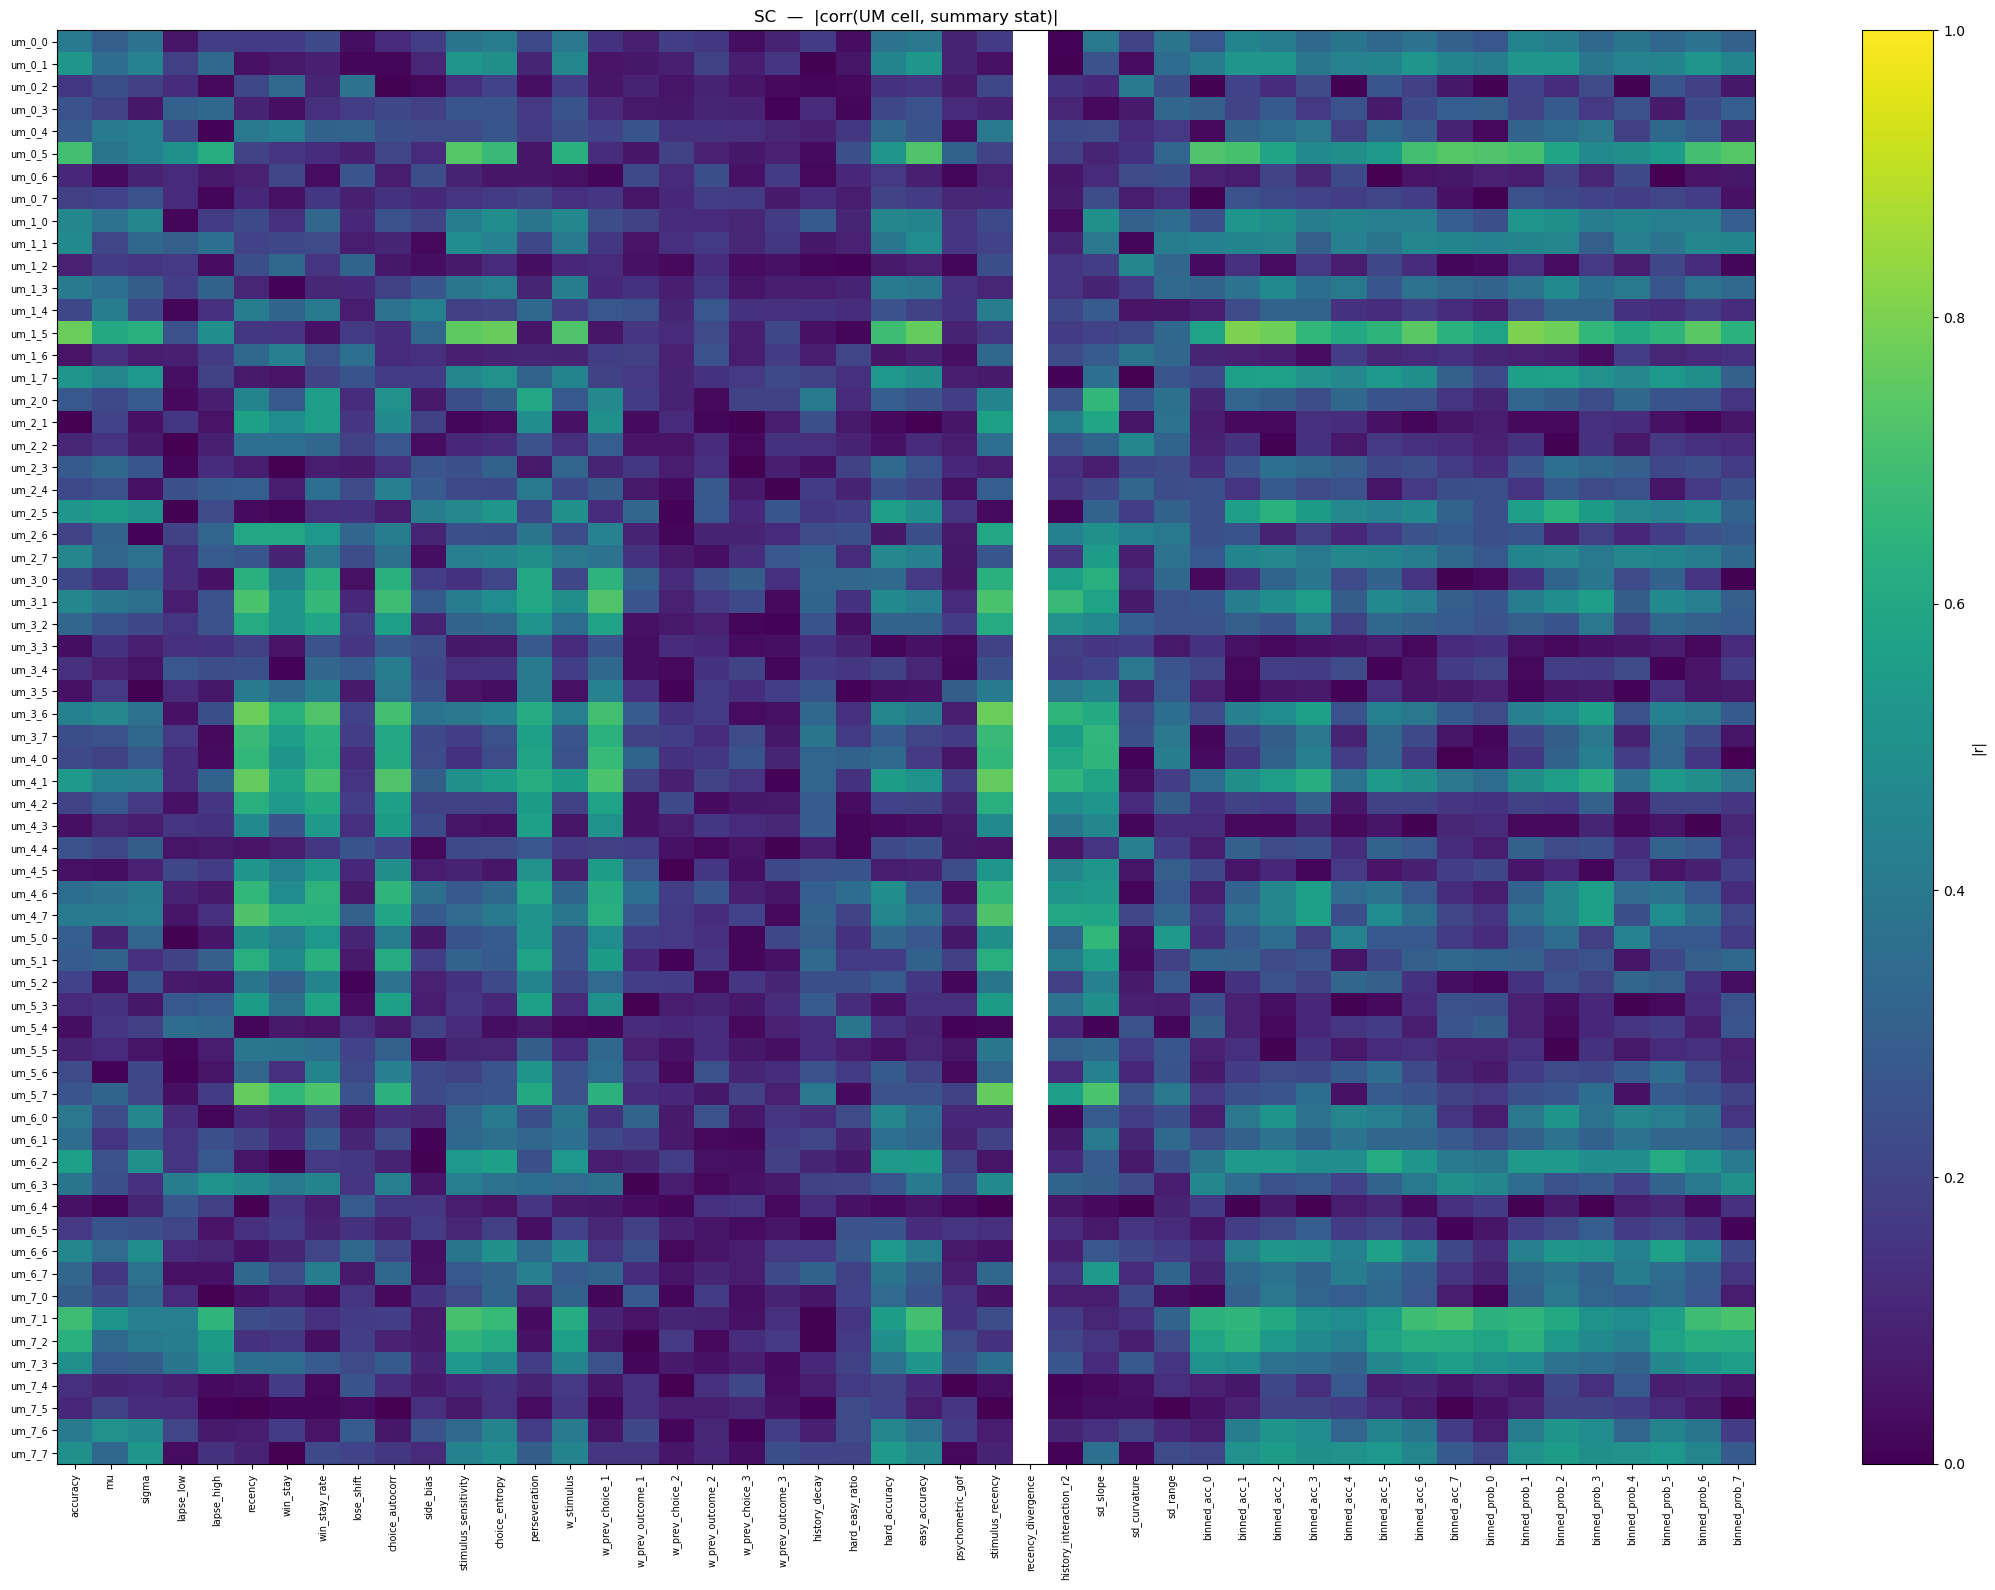

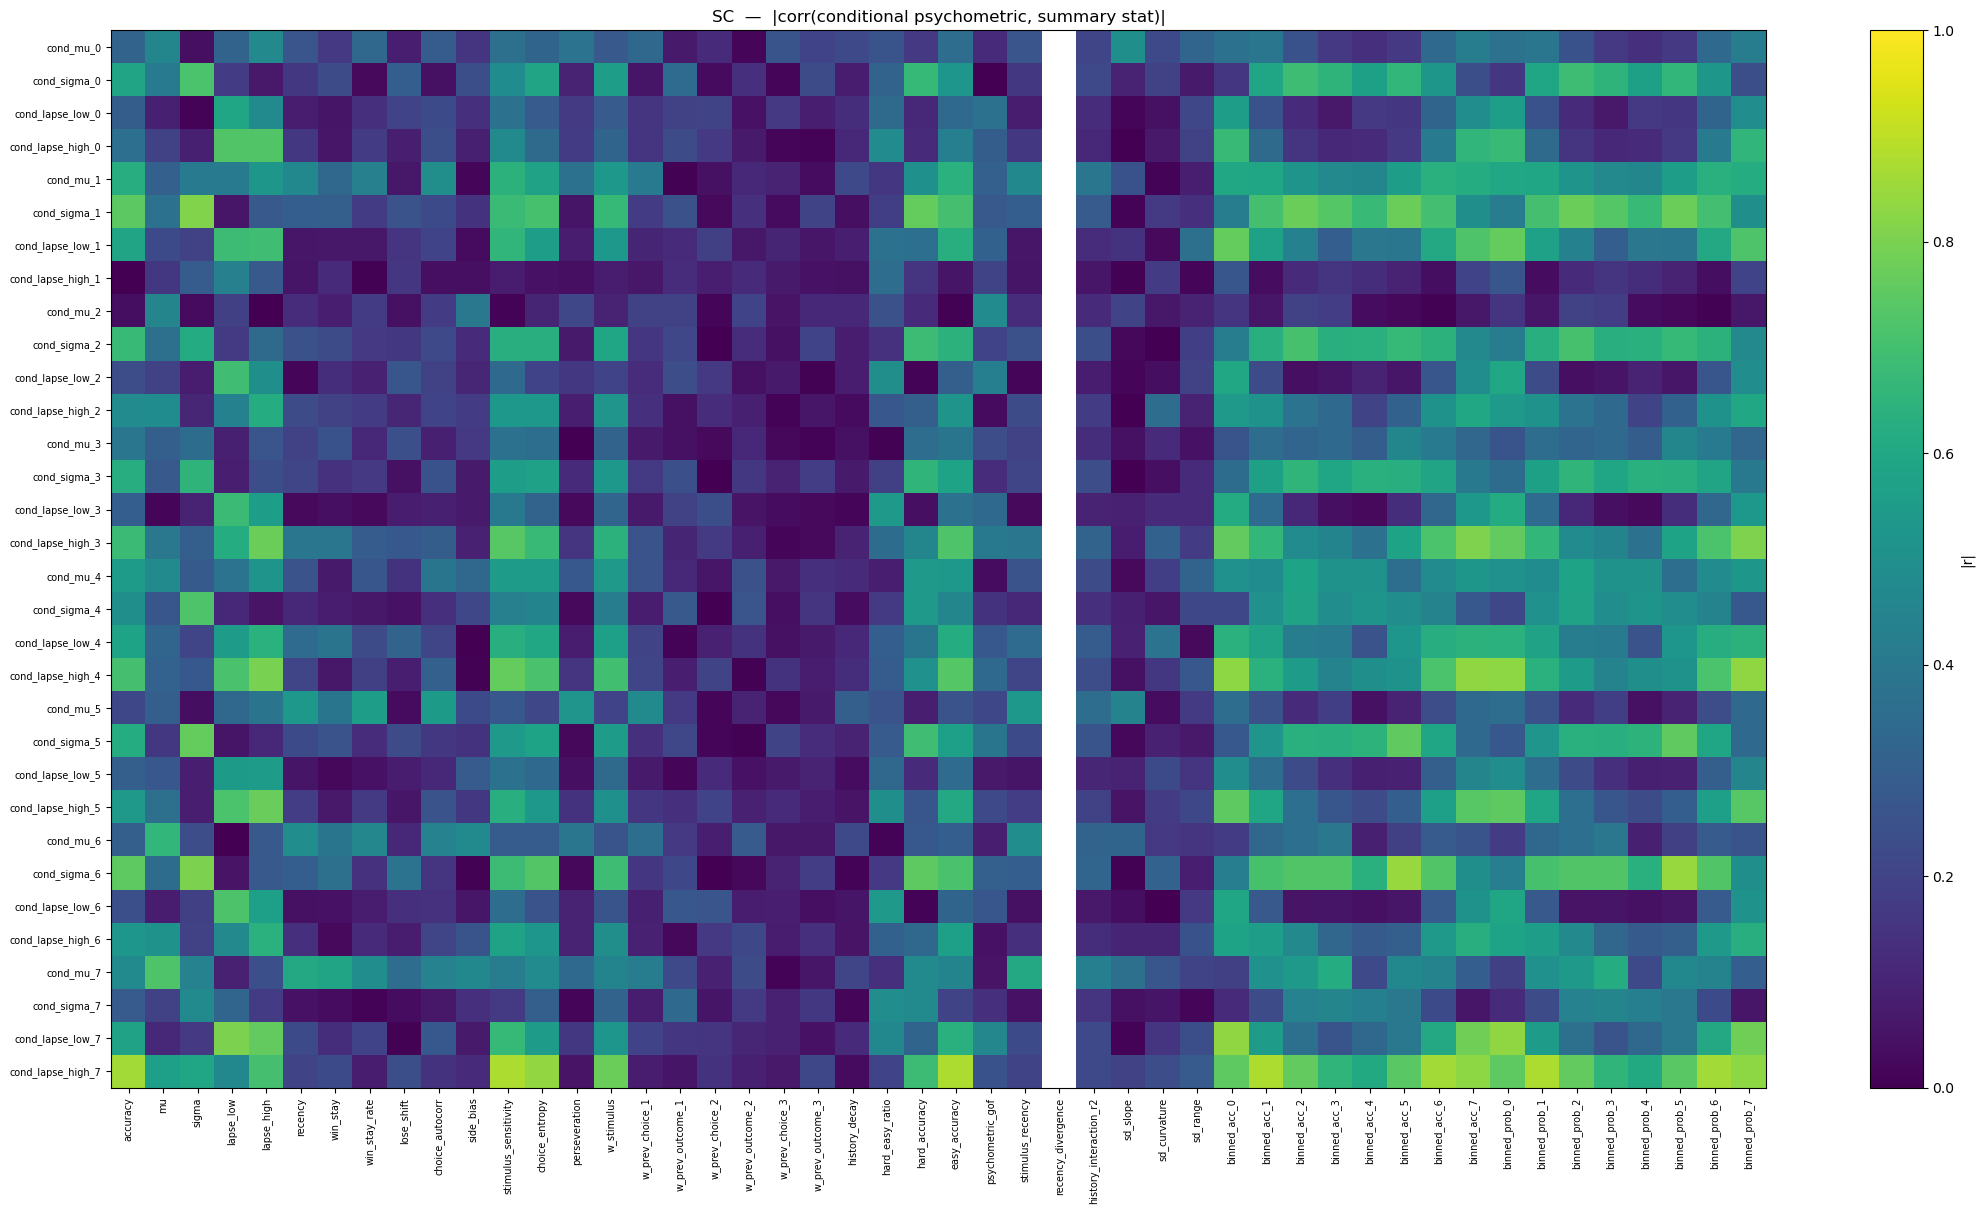

In [5]:
for label, res in [('BE', be), ('SC', sc)]:
    names = res['stat_names_expanded']
    feat_idx, um_idx, cond_idx = stat_groups(names)
    feat_names = [names[k] for k in feat_idx]
    x = res['x']
    plot_cross(cross_corr(x[:, um_idx],   x[:, feat_idx]),
               [names[k] for k in um_idx],   feat_names, f'{label}  —  |corr(UM cell, summary stat)|')
    plot_cross(cross_corr(x[:, cond_idx], x[:, feat_idx]),
               [names[k] for k in cond_idx], feat_names, f'{label}  —  |corr(conditional psychometric, summary stat)|')

## Real Data

The same UM/cond-psych-vs-feature cross-correlation, computed across real per-session stats.

**Two caveats — this is a sanity check, not the primary evidence:**

1. It measures empirical co-variation across *heterogeneous* sessions — animal identity, learning
   stage, distribution phase and opto condition all vary at once. That is a different question from
   the synthetic test, which holds the model family fixed and varies only parameters.
2. Per-session UMs are sparse, so most UM cells are NaN in most sessions. The correlations use
   pairwise-complete observations, meaning a sparse cell's value rests on whatever few sessions
   have it — or is undefined (blank). Do not over-read individual UM cells here.

In [6]:
experiment, info = load_data()
print(f"Mode: {info['mode']}")

stat_names = list_available_stats()
expanded   = get_stat_names_expanded(stat_names)

rows = []
for animal_id in experiment.animal_ids:
    sessions = experiment.get_animal(animal_id).get_sessions()
    res = compute_summary_stats(sessions, stat_names=stat_names, mode='per_session')
    for s in res['per_session']:
        rows.append(flatten_stats(s['stats']))

real_x = np.array(rows, dtype=float)
assert real_x.shape[1] == len(expanded), (real_x.shape, len(expanded))
print(f"{real_x.shape[0]} sessions x {real_x.shape[1]} expanded stats")

/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/notebooks/shared_setup.py:188: UserWarning: Snapshot is 405h old (exported 2026-06-09T12:49:35.485965+00:00). Re-export if new sessions have been collected.
  experiment, meta = load_snapshot(


Loaded snapshot: 22 animals, 1185 sessions (exported 2026-06-09)
Mode: snapshot
1183 sessions x 144 expanded stats


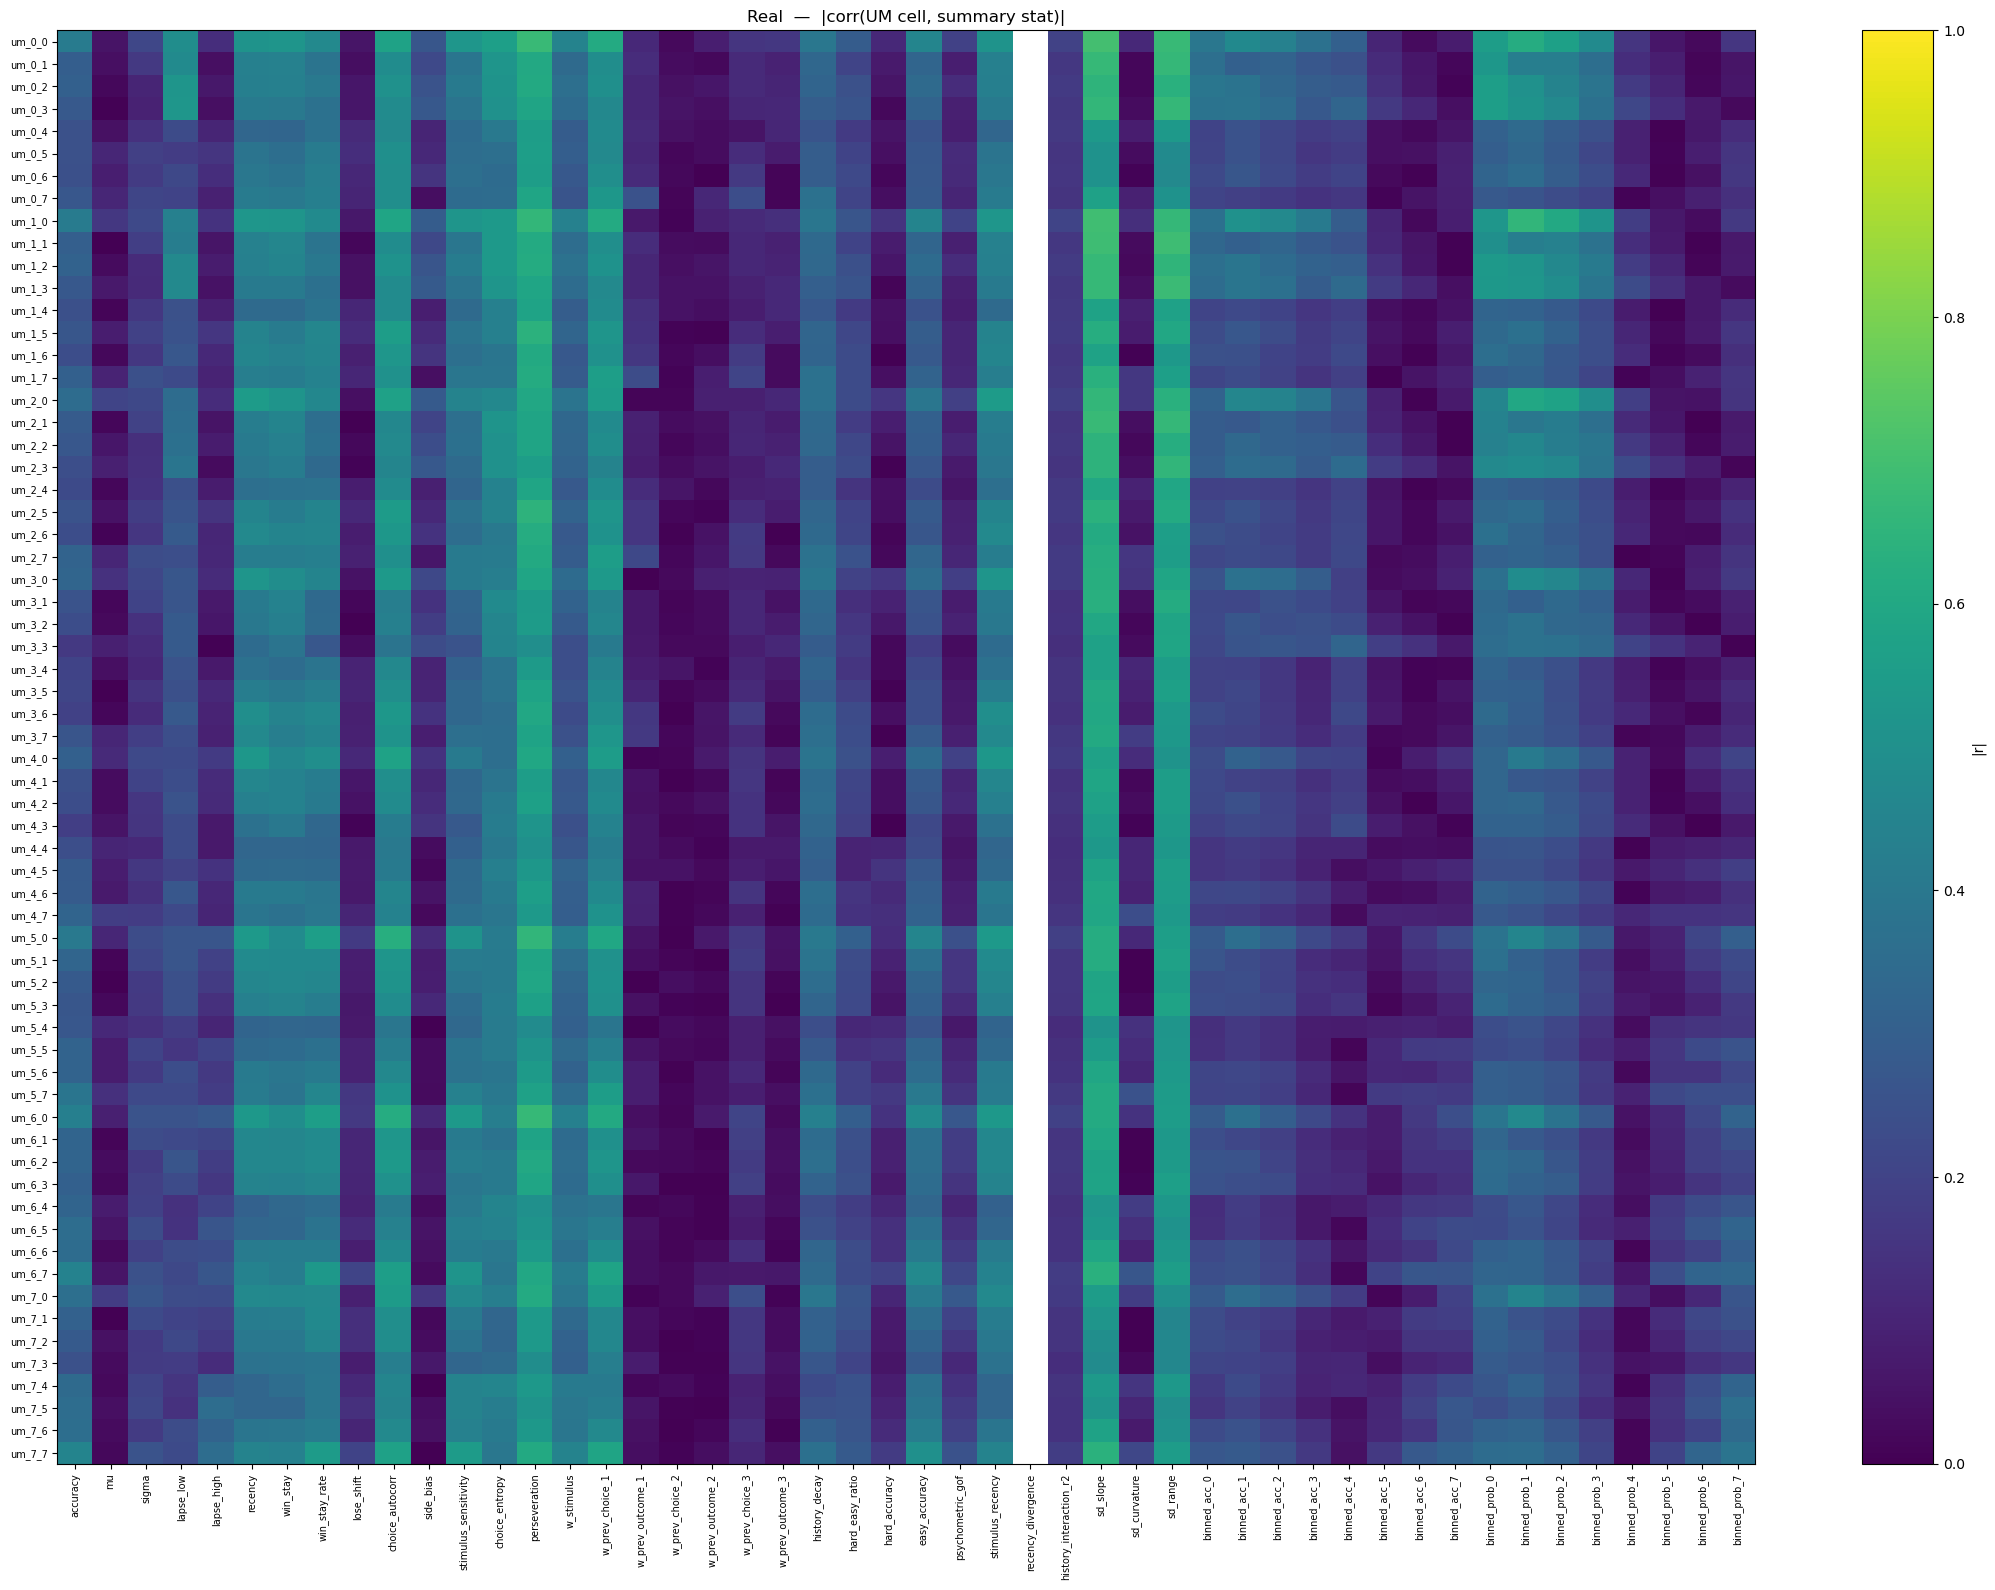

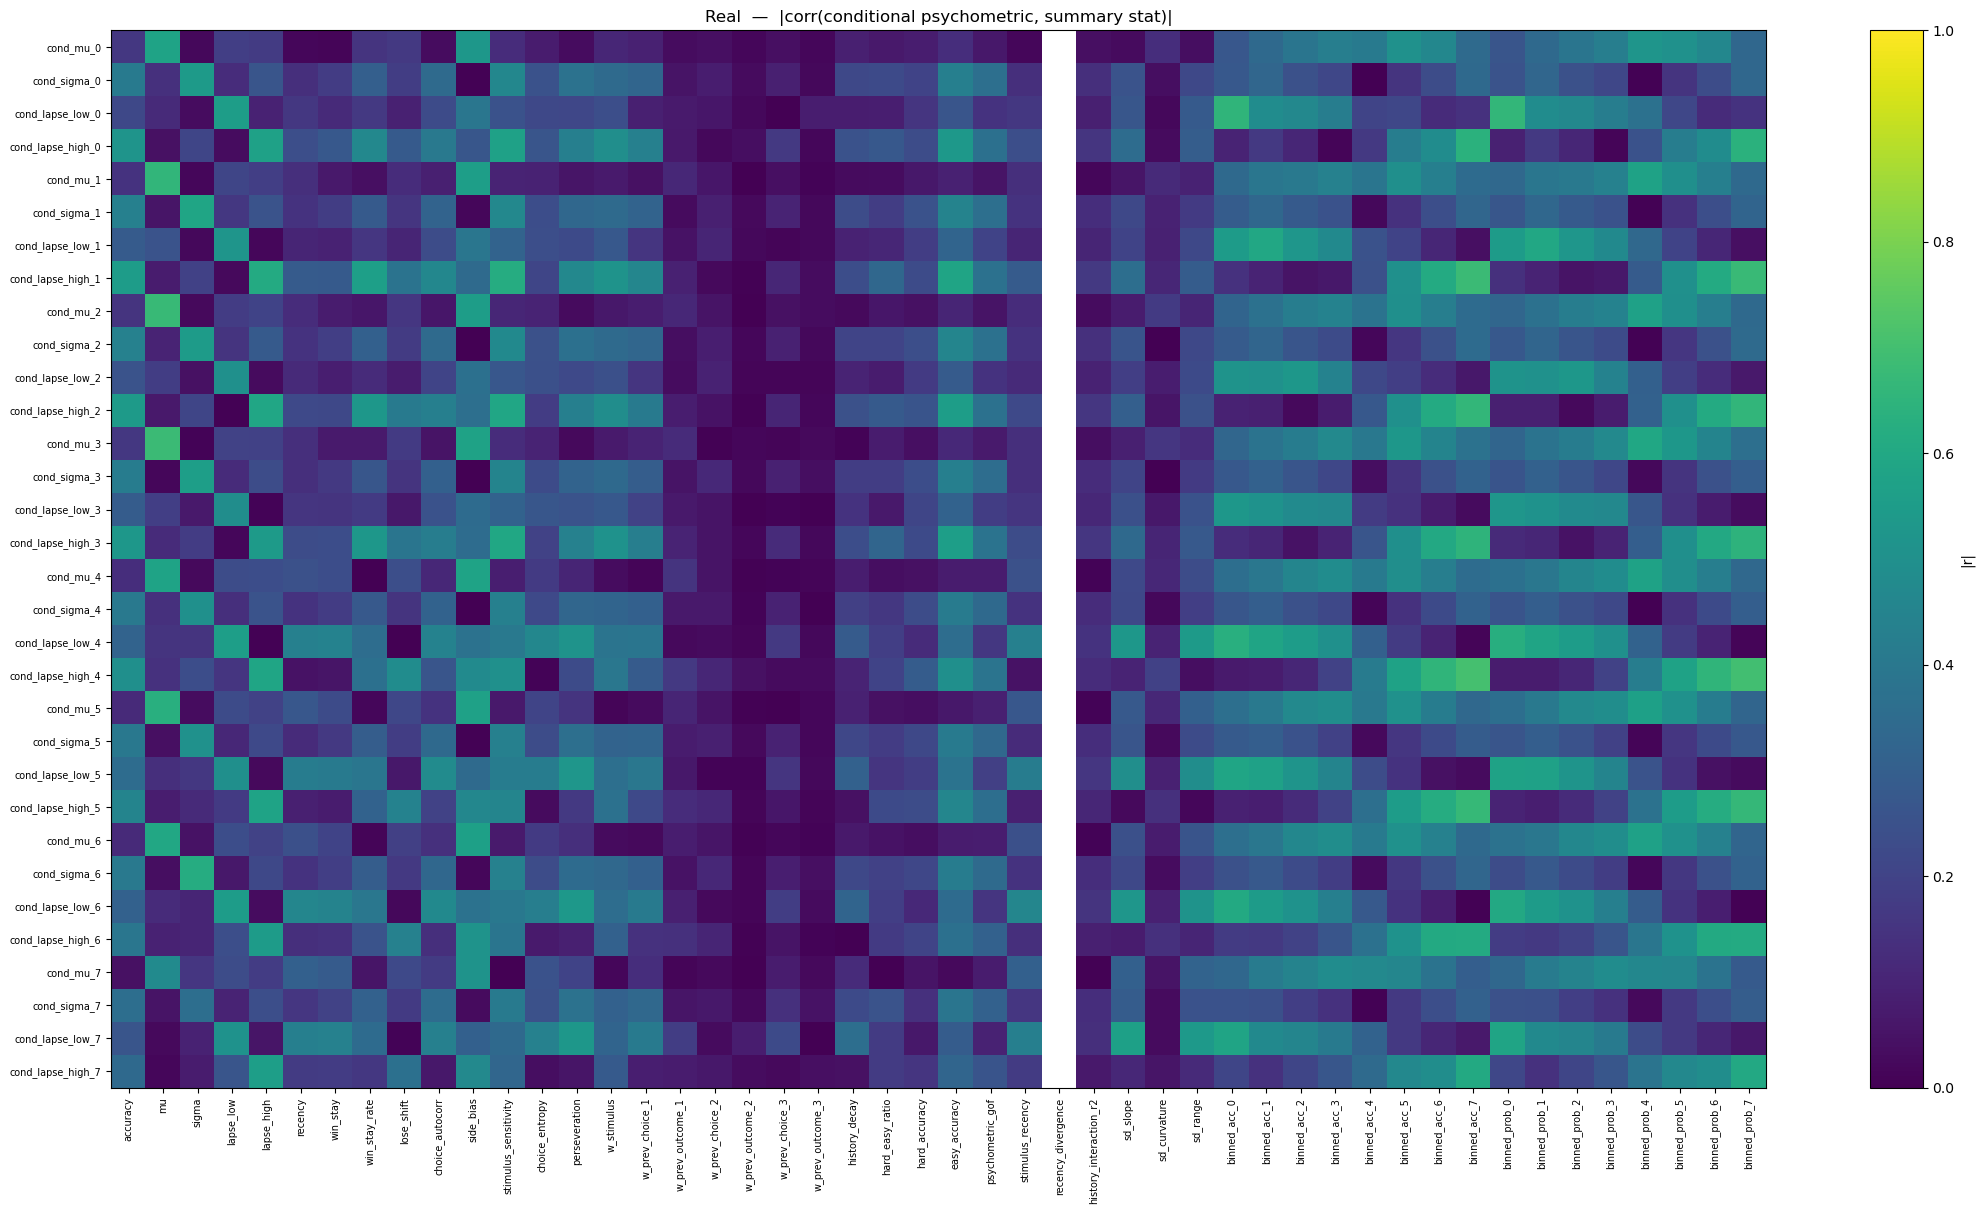

In [7]:
feat_idx, um_idx, cond_idx = stat_groups(expanded)
feat_names = [expanded[k] for k in feat_idx]

plot_cross(cross_corr(real_x[:, um_idx],   real_x[:, feat_idx]),
           [expanded[k] for k in um_idx],   feat_names, 'Real  —  |corr(UM cell, summary stat)|')
plot_cross(cross_corr(real_x[:, cond_idx], real_x[:, feat_idx]),
           [expanded[k] for k in cond_idx], feat_names, 'Real  —  |corr(conditional psychometric, summary stat)|')